In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/strixhaven_clean.csv")
print(df.shape)
df.head()

(264, 8)


,name,text,manaCost,type,rarity,keywords,games_in_hand,win_rate
0,The Dawning Archaic,This spell costs {1} less to cast for each ins...,{10},Legendary Creature — Avatar,mythic,['Reach'],10289,0.538
1,Rancorous Archaic,"Reach, trample\nConverge — This creature enter...",{5},Creature — Avatar,common,"['Converge', 'Reach', 'Trample']",39543,0.536
2,Sundering Archaic,"Converge — When this creature enters, exile ta...",{6},Creature — Avatar,uncommon,['Converge'],67627,0.588
3,Together as One,"Converge — Target player draws X cards, Togeth...",{6},Sorcery,rare,['Converge'],37273,0.656
4,Transcendent Archaic,Vigilance\nConverge — When this creature enter...,{7},Creature — Avatar,uncommon,"['Converge', 'Vigilance']",43681,0.570


In [7]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           264 non-null    str    
 1   text           264 non-null    str    
 2   manaCost       251 non-null    str    
 3   type           264 non-null    str    
 4   rarity         264 non-null    str    
 5   keywords       154 non-null    str    
 6   games_in_hand  264 non-null    int64  
 7   win_rate       264 non-null    float64
dtypes: float64(1), int64(1), str(6)
memory usage: 78.0 KB


,games_in_hand,win_rate
count,264.000000,264.000000
mean,46143.784091,0.554799
std,37917.995838,0.036059
min,1342.000000,0.443000
25%,20143.500000,0.532750
50%,33489.000000,0.557500
75%,60588.250000,0.578000
max,177681.000000,0.656000


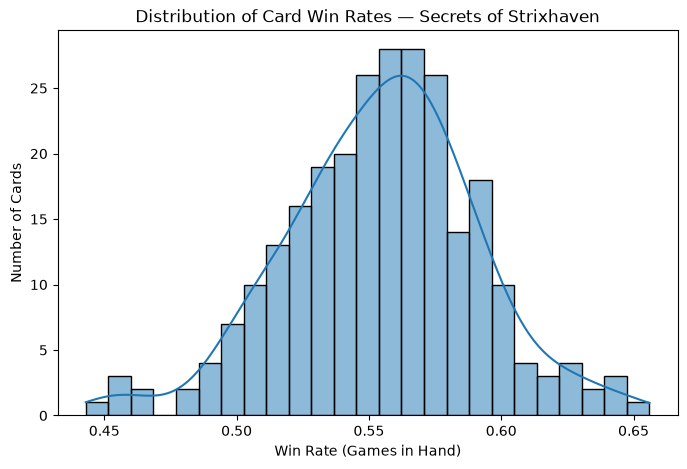

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df["win_rate"], bins=25, kde=True)
plt.title("Distribution of Card Win Rates — Secrets of Strixhaven")
plt.xlabel("Win Rate (Games in Hand)")
plt.ylabel("Number of Cards")
plt.savefig("../notebooks/win_rate_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

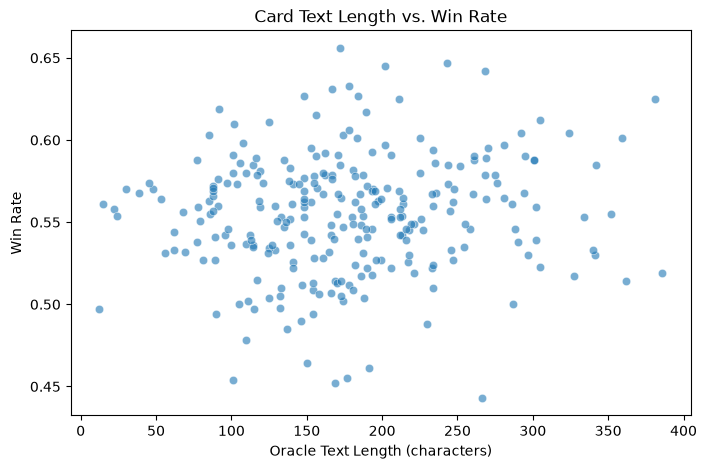

Correlation between text length and win rate: 0.099


In [9]:
df["text_length"] = df["text"].astype(str).str.len()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="text_length", y="win_rate", alpha=0.6)
plt.title("Card Text Length vs. Win Rate")
plt.xlabel("Oracle Text Length (characters)")
plt.ylabel("Win Rate")
plt.savefig("../notebooks/text_length_vs_winrate.png", dpi=150, bbox_inches="tight")
plt.show()

correlation = df["text_length"].corr(df["win_rate"])
print(f"Correlation between text length and win rate: {correlation:.3f}")

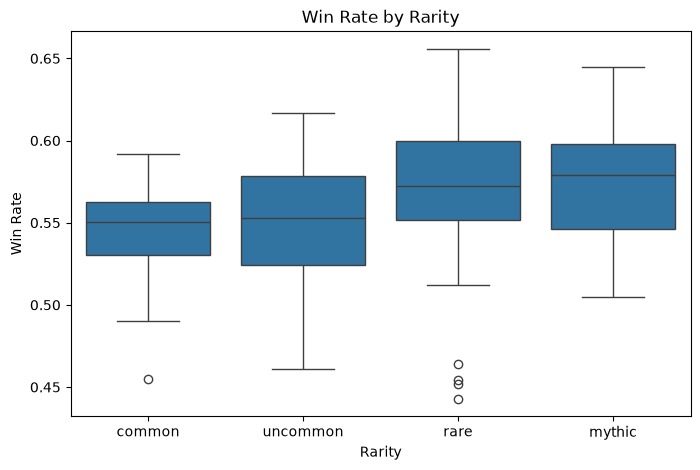

In [10]:
rarity_order = ["common", "uncommon", "rare", "mythic"]

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="rarity", y="win_rate", order=rarity_order)
plt.title("Win Rate by Rarity")
plt.xlabel("Rarity")
plt.ylabel("Win Rate")
plt.savefig("../notebooks/winrate_by_rarity.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
print("TOP 10 by win rate:")
top10 = df.sort_values("win_rate", ascending=False).head(10)
for _, row in top10.iterrows():
    print(f"  {row['win_rate']:.3f}  {row['name']}")

print("\nBOTTOM 10 by win rate:")
bottom10 = df.sort_values("win_rate", ascending=True).head(10)
for _, row in bottom10.iterrows():
    print(f"  {row['win_rate']:.3f}  {row['name']}")

TOP 10 by win rate:
  0.656  Together as One
  0.647  Practiced Offense
  0.645  Emeritus of Ideation // Ancestral Recall
  0.642  Antiquities on the Loose
  0.633  Moment of Reckoning
  0.631  Ark of Hunger
  0.627  Stirring Hopesinger
  0.627  Professor Dellian Fel
  0.625  Colorstorm Stallion
  0.625  Improvisation Capstone

BOTTOM 10 by win rate:
  0.443  Choreographed Sparks
  0.452  Comforting Counsel
  0.454  Dina's Guidance
  0.455  Biblioplex Tomekeeper
  0.461  Borrowed Knowledge
  0.464  Fix What's Broken
  0.478  Growth Curve
  0.485  Fractal Anomaly
  0.488  Daydream
  0.490  Ulna Alley Shopkeep
